In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score
import pandas as pd
import numpy as np
import os

os.chdir('../../../results/PlantCAD2_tasks/')

In [2]:
species  = ['arabidopsis_thaliana', 'eutrema_salsugineum',
            'brachypodium_distachyon', 'oryza_sativa']
contexts = ['c600']
ckpts = ['pcv2-l24-d0768-checkpoints-lr-1e-4', 'debug_brachypodium_pcv2-l24-d0768-checkpoints-lr-1e-4', 'exclude-genic-pcv2-l24-d0768-checkpoints-lr-1e-4']

In [3]:
results = []

for ckpt in ckpts:
    for i, sp in enumerate(species):
        if sp == 'arabidopsis_thaliana':
            scores_path = (
                f'accessible_angiosperm_c600/models/{ckpt}/'
                f'valid_scores.tsv'
            )
            labels_path = f'accessible_angiosperm_c600/data/valid.tsv'
        else:
            scores_path = (
                f'accessible_angiosperm_c600/models/{ckpt}/'
                f'test_{sp}_scores.tsv'
            )
            labels_path = f'accessible_angiosperm_c600/data/test_{sp}.tsv'
        
        preds = pd.read_csv(scores_path, sep='\t')
        labs = pd.read_csv(labels_path, sep='\t')

        if 'exclude' in ckpt:
            labs = labs[labs['Type'] != 'genic']
        
        y_scores = preds['probability_positive']
        y_true = labs['Label']
        
        auroc = roc_auc_score(y_true, y_scores)
        auprc = average_precision_score(y_true, y_scores)
        
        results.append({
            'test_sp': sp,
            'checkpoint': ckpt,
            'AUROC': auroc,
            'AUPRC': auprc,
            'baseline': np.mean(y_true)
        })

results_df = pd.DataFrame(results)

In [4]:
results_df['AUROC'] = results_df['AUROC'].map('{:.4f}'.format)
results_df['AUPRC'] = results_df['AUPRC'].map('{:.4f}'.format)
results_df['baseline'] = results_df['baseline'].map('{:.4f}'.format)

results_df['train_sp'] = results_df['checkpoint'].apply(
    lambda x: 'ath-exclude-genic' if 'exclude' in x else (
        'brachy' if 'debug' in x else 'ath'
    )
)

In [5]:
results_df

,test_sp,checkpoint,AUROC,AUPRC,baseline,train_sp
0,arabidopsis_thaliana,pcv2-l24-d0768-checkpoints-lr-1e-4,0.9697,0.7882,0.0861,ath
1,eutrema_salsugineum,pcv2-l24-d0768-checkpoints-lr-1e-4,0.9267,0.5246,0.0377,ath
2,brachypodium_distachyon,pcv2-l24-d0768-checkpoints-lr-1e-4,0.8081,0.2761,0.0316,ath
3,oryza_sativa,pcv2-l24-d0768-checkpoints-lr-1e-4,0.8960,0.5113,0.0390,ath
4,arabidopsis_thaliana,debug_brachypodium_pcv2-l24-d0768-checkpoints-...,0.8069,0.4106,0.0861,brachy
5,eutrema_salsugineum,debug_brachypodium_pcv2-l24-d0768-checkpoints-...,0.7448,0.2037,0.0377,brachy
6,brachypodium_distachyon,debug_brachypodium_pcv2-l24-d0768-checkpoints-...,0.9505,0.5751,0.0316,brachy
7,oryza_sativa,debug_brachypodium_pcv2-l24-d0768-checkpoints-...,0.9378,0.5566,0.0390,brachy
8,arabidopsis_thaliana,exclude-genic-pcv2-l24-d0768-checkpoints-lr-1e-4,0.9516,0.7932,0.1481,ath-exclude-genic
9,eutrema_salsugineum,exclude-genic-pcv2-l24-d0768-checkpoints-lr-1e-4,0.9267,0.5376,0.0413,ath-exclude-genic


In [6]:
sorted_results_df = results_df.sort_values(by='train_sp').drop('checkpoint', axis=1)[['train_sp', 'test_sp', 'AUROC', 'AUPRC', 'baseline']]

In [7]:
sorted_results_df

,train_sp,test_sp,AUROC,AUPRC,baseline
0,ath,arabidopsis_thaliana,0.9697,0.7882,0.0861
1,ath,eutrema_salsugineum,0.9267,0.5246,0.0377
2,ath,brachypodium_distachyon,0.8081,0.2761,0.0316
3,ath,oryza_sativa,0.8960,0.5113,0.0390
8,ath-exclude-genic,arabidopsis_thaliana,0.9516,0.7932,0.1481
9,ath-exclude-genic,eutrema_salsugineum,0.9267,0.5376,0.0413
10,ath-exclude-genic,brachypodium_distachyon,0.8346,0.3168,0.0393
11,ath-exclude-genic,oryza_sativa,0.8842,0.5185,0.0453
4,brachy,arabidopsis_thaliana,0.8069,0.4106,0.0861
5,brachy,eutrema_salsugineum,0.7448,0.2037,0.0377


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sorted_results_df['AUROC'] = sorted_results_df['AUROC'].astype(float)
sorted_results_df['AUPRC'] = sorted_results_df['AUPRC'].astype(float)
sorted_results_df['baseline'] = sorted_results_df['baseline'].astype(float)


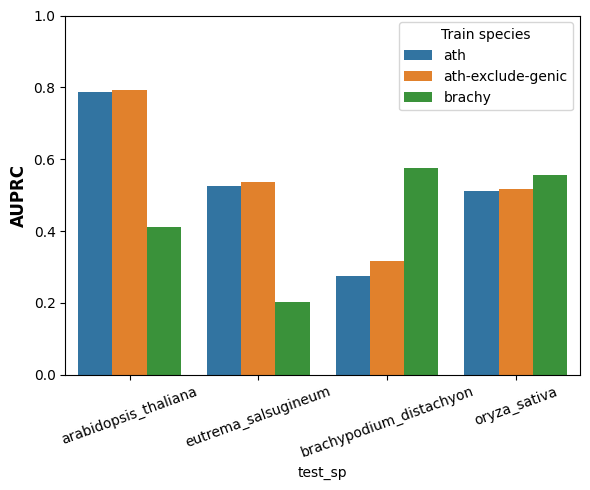

In [10]:
plt.figure(figsize=(6, 5))
colors = ['C0', 'C1', 'C2']

sns.barplot(
    data=sorted_results_df,
    x='test_sp',
    y='AUPRC',
    hue='train_sp',
    palette=colors
)

plt.ylabel('AUPRC', fontsize=12, fontweight='bold')
plt.xticks(rotation=20)
plt.legend(title='Train species')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../../pipelines/lu_2019_ATACseq/figures/debug_brachy_aupr_barplots.pdf', format='pdf', bbox_inches='tight')
plt.show()